# FIDE Ratings Analysis!

## Building the longitudinal dataset

Downloads every monthly FIDE rating list from July 2015 to today and parses each one into a typed parquet file. Unlike v1 (which loaded all 1.8M players into memory at once and crashed), this streams through the XML one player at a time, filters out unrated entries, and writes in chunks — so peak memory stays flat regardless of file size. Fully resumable: re-running skips anything already on disk.

Before any analysis, we need the raw data in a form we can actually work with. This section downloads every FIDE monthly rating list from July 2015 onward, filters out unrated players, converts types, and saves each month as its own parquet file. It's the "prep work" — run once, then every analysis below just loads what it needs.

Run time of this cell: Roughly 10 minutes in total, but it's fully resumable and safe to interrupt. It checks for existing files before downloading or processing, so if you stop it halfway, just run it again and it'll pick up where it left off.

**Note on rate limiting:**
 There is a 1-second pause between each file download (`SLEEP_BETWEEN = 1.0`). This is standard web scraping etiquette — hitting a server with 130 rapid requests risks getting your IP blocked and degrades the experience for other users on the site. The delay keeps the pipeline polite and stable. Adjust `SLEEP_BETWEEN` in `fide_pipeline.py` if needed, but don't set it below `0.5`.

In [12]:
from build_dataset import load_snapshots, load_snapshot_counts

## Sense check

Coverage, sex breakdown, top players, and a quick timeline plot.

In [13]:
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path("data/fide_parquet")
files = sorted(PARQUET_DIR.glob("*.parquet"))
latest = pd.read_parquet(files[-1])

print(f"{len(files)} months  •  {files[0].stem} → {files[-1].stem}")
print(f"{len(latest):,} active players in {files[-1].stem}  ({(latest.sex == 'F').mean()*100:.1f}% female)")
print(f"{sum(f.stat().st_size for f in files)/1e9:.2f} GB on disk\n")

cols = ["name", "country", "rating", "birthday"]
display(latest[latest.sex == "M"].nlargest(5, "rating")[cols].reset_index(drop=True))
display(latest[latest.sex == "F"].nlargest(5, "rating")[cols].reset_index(drop=True))

130 months  •  2015-07 → 2026-04
545,549 active players in 2026-04  (11.0% female)
1.10 GB on disk



,name,country,rating,birthday
0,"Carlsen, Magnus",NOR,2840,1990.0
1,"Kasparov, Garry",RUS,2812,1963.0
2,"Nakamura, Hikaru",USA,2810,1987.0
3,"Caruana, Fabiano",USA,2793,1992.0
4,"Abdusattorov, Nodirbek",UZB,2780,2004.0


,name,country,rating,birthday
0,"Polgar, Judit",HUN,2675,1976.0
1,"Hou, Yifan",CHN,2596,1994.0
2,"Polgar, Susan",HUN,2577,1969.0
3,"Xie, Jun",CHN,2574,1970.0
4,"Lei, Tingjie",CHN,2566,1997.0


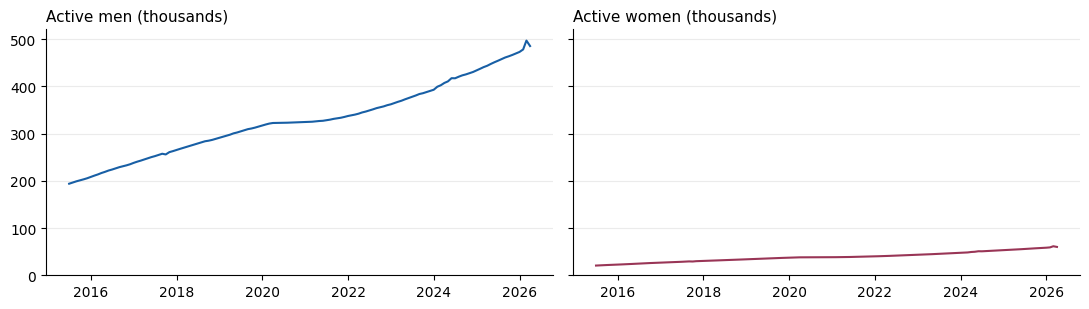

In [14]:
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

dataset = ds.dataset("data/fide_parquet", format="parquet")

def counts(sex):
    t = dataset.to_table(columns=["snapshot_date", "fideid"], filter=ds.field("sex") == sex)
    return t.to_pandas().groupby("snapshot_date").size().rename("n").reset_index()

m, f = counts("M"), counts("F")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True, sharey=True)
ax1.plot(m.snapshot_date, m.n/1000, color="#185FA5", lw=1.5)
ax1.set_title("Active men (thousands)", loc="left", fontsize=11)
ax2.plot(f.snapshot_date, f.n/1000, color="#993556", lw=1.5)
ax2.set_title("Active women (thousands)", loc="left", fontsize=11)
for ax in (ax1, ax2):
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

In [15]:
import pyarrow.dataset as ds

fide_all = ds.dataset("data/fide_parquet", format="parquet")

#### As a note the full dataset is called fide_all and the snapshot of the most recent month is called latest.

### Question 1: Queen's Gambit effect — did the show cause a surge in new female players?

The Queen's Gambit premiered on Netflix in October 2020 and became a cultural phenomenon, sparking widespread interest in chess. To investigate whether the show led to a surge in new female players, we can analyze the monthly counts of active female players in the FIDE dataset before and after the show's release.

Text(0.0, 1.0, 'Active Female Players in 2020')

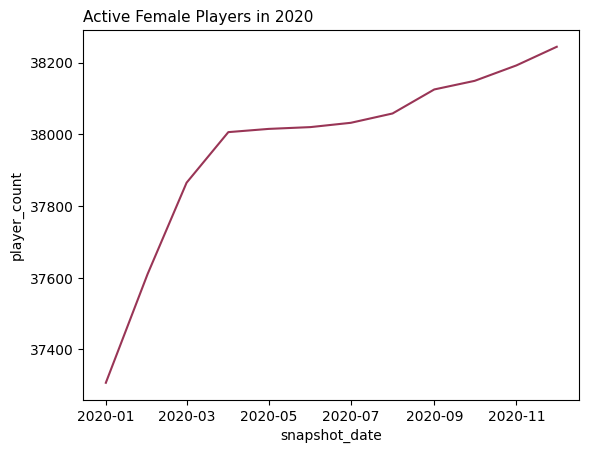

In [19]:
from datetime import date
import seaborn as sns

df = load_snapshot_counts(sex="F")
df_2020 = df[(df.snapshot_date >= date(2020, 1, 1)) & (df.snapshot_date <= date(2020, 12, 1))]

sns.lineplot(df_2020, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players in 2020", loc="left", fontsize=11)


Text(0.0, 1.0, 'Active Female Players in 2021')

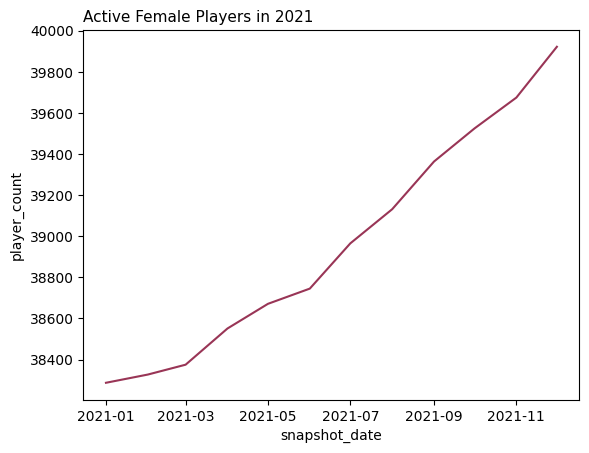

In [20]:
from datetime import date
import seaborn as sns

df = load_snapshot_counts(sex="F")
df_2021 = df[(df.snapshot_date >= date(2021, 1, 1)) & (df.snapshot_date <= date(2021, 12, 1))]

sns.lineplot(df_2021, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players in 2021", loc="left", fontsize=11)

(array([18262., 18353., 18444., 18536., 18628., 18718., 18809., 18901.,
        18993.]),
 [Text(18262.0, 0, '2020-01'),
  Text(18353.0, 0, '2020-04'),
  Text(18444.0, 0, '2020-07'),
  Text(18536.0, 0, '2020-10'),
  Text(18628.0, 0, '2021-01'),
  Text(18718.0, 0, '2021-04'),
  Text(18809.0, 0, '2021-07'),
  Text(18901.0, 0, '2021-10'),
  Text(18993.0, 0, '2022-01')])

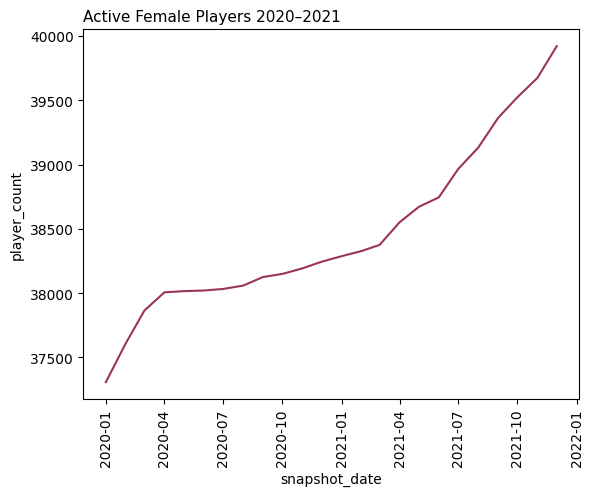

In [21]:
df = load_snapshot_counts(sex="F")
df_2020_21 = df[(df.snapshot_date >= date(2020, 1, 1)) & (df.snapshot_date <= date(2021, 12, 1))]

sns.lineplot(df_2020_21, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players 2020–2021", loc="left", fontsize=11)
plt.xticks(rotation=90)

In [22]:
# New sign-ups = players appearing in the dataset for the first time that year
df_first = load_snapshots(columns=["fideid", "snapshot_date"], sex="F")
first_seen = df_first.groupby("fideid")["snapshot_date"].min().reset_index()
first_seen["year"] = pd.to_datetime(first_seen["snapshot_date"]).dt.year

new_by_year = first_seen.groupby("year").size().rename("new_signups")

n2019 = new_by_year[2019]
n2020 = new_by_year[2020]
n2021 = new_by_year[2021]

pct_2020 = (n2020 - n2019) / n2019 * 100
pct_2021 = (n2021 - n2020) / n2020 * 100
pct_diff = pct_2021 - pct_2020

print(f"New female sign-ups:")
print(f"  2019: {n2019:,}")
print(f"  2020: {n2020:,}  ({pct_2020:+.1f}% vs 2019)")
print(f"  2021: {n2021:,}  ({pct_2021:+.1f}% vs 2020)")
print(f"\nPercentage point difference (2021 growth vs 2020 growth): {pct_diff:+.1f} pp")

New female sign-ups:
  2019: 3,766
  2020: 1,294  (-65.6% vs 2019)
  2021: 1,762  (+36.2% vs 2020)

Percentage point difference (2021 growth vs 2020 growth): +101.8 pp


2019 saw 3,766 new girls and women sign ups while 2020 had 1,294 a -65.6% drop. 2021 the year after the queens gambit released had 1,762 sign ups which is a 36.1% increase from 2020 but still a -53.2% drop from 2019. So while there was an increase in new female players in 2021 compared to 2020, it did not fully recover to the levels seen in 2019, and the overall trend from 2019 to 2021 still shows a significant decline in new female sign-ups. This suggests that while the Queen's Gambit may have had some positive impact on interest in chess among women, it was not enough to reverse the overall downward trend in new female players during this period.

### Interrupted Time Series (ITS) model

The exploratory plots above show a visual bump, but they don't tell us whether it's bigger than what the pre-existing growth trend would predict. There's also a confound: 2020 saw a big drop in new sign-ups, almost certainly due to COVID-19 closing in-person tournaments. The ITS model separates these effects by fitting the pre-trend explicitly and asking whether the post-Oct-2020 trajectory diverges from it.

The model estimates three things:
- **`t` (trend)** — the pre-existing monthly growth rate
- **`post` (level)** — did the count jump immediately at the intervention?
- **`t_post` (slope change)** — did the monthly growth rate change after the intervention?

We use Newey-West HAC standard errors because monthly counts are correlated with last month's counts — ignoring this makes p-values too small. Male players are run as a control group: a real Queen's Gambit effect should appear in the female series but not (or much less) in the male series.

In [25]:
import numpy as np
import statsmodels.api as sm

intervention = date(2020, 10, 1)

def build_its_df(sex):
    df = load_snapshot_counts(sex=sex).sort_values("snapshot_date").reset_index(drop=True)
    df["t"] = np.arange(len(df))
    df["post"] = (df["snapshot_date"] >= intervention).astype(int)
    df["t_post"] = df["t"] * df["post"]
    return df

def fit_its(df):
    X = sm.add_constant(df[["t", "post", "t_post"]])
    return sm.OLS(df["player_count"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

df_f = build_its_df("F")
df_m = build_its_df("M")

res_f = fit_its(df_f)
res_m = fit_its(df_m)

print("=== FEMALE players ===")
print(res_f.summary2().tables[1])
print("\n=== MALE players (control) ===")
print(res_m.summary2().tables[1])

=== FEMALE players ===
               Coef.     Std.Err.          z     P>|z|        [0.025  \
const   21227.334325   222.415748  95.439889  0.000000  20791.407470   
t         295.578053     7.266063  40.679258  0.000000    281.336831   
post    -7988.350209  1995.969674  -4.002240  0.000063 -11900.378884   
t_post     53.550688    19.432371   2.755746  0.005856     15.463940   

              0.975]  
const   21663.261181  
t         309.819275  
post    -4076.321533  
t_post     91.637436  

=== MALE players (control) ===
                Coef.      Std.Err.           z     P>|z|         [0.025  \
const   197634.225694   1494.692832  132.223974  0.000000  194704.681575   
t         2199.676795     51.238999   42.929738  0.000000    2099.250202   
post    -60239.420363  14747.512087   -4.084717  0.000044  -89144.012914   
t_post     404.001072    140.923821    2.866805  0.004146     127.795458   

               0.975]  
const   200563.769814  
t         2300.103389  
post    -31334.8

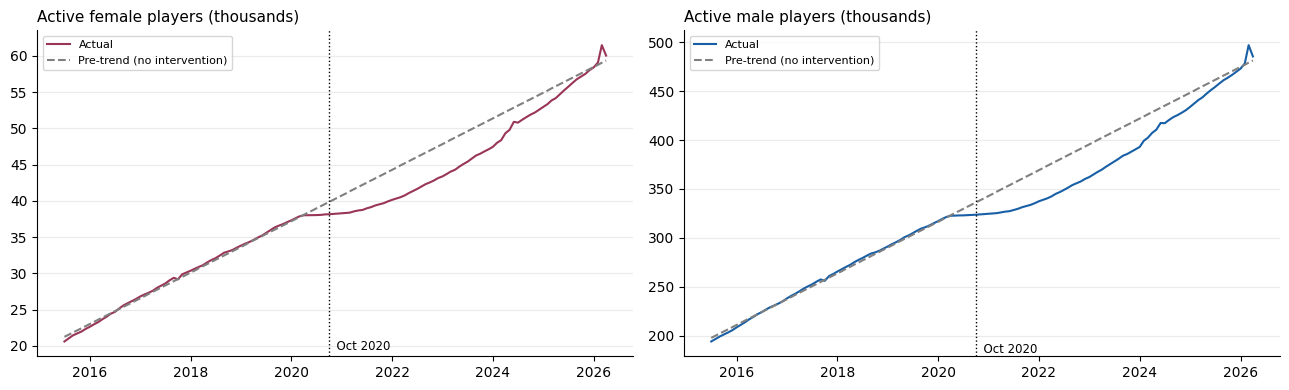

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, df, res, color, label in [
    (ax1, df_f, res_f, "#993556", "Female"),
    (ax2, df_m, res_m, "#185FA5", "Male"),
]:
    dates = pd.to_datetime(df["snapshot_date"])
    actual = df["player_count"] / 1000

    # Counterfactual: pre-trend only (post=0, t_post=0)
    pre_only = df[["t"]].copy()
    pre_only["post"] = 0
    pre_only["t_post"] = 0
    X_cf = sm.add_constant(pre_only)
    counterfactual = res.predict(X_cf) / 1000

    ax.plot(dates, actual, color=color, lw=1.5, label="Actual")
    ax.plot(dates, counterfactual, color="grey", lw=1.5, ls="--", label="Pre-trend (no intervention)")
    ax.axvline(pd.Timestamp(intervention), color="black", lw=1, ls=":")
    ax.text(pd.Timestamp(intervention), ax.get_ylim()[0] + 0.5,
            "  Oct 2020", va="bottom", fontsize=8.5)
    ax.set_title(f"Active {label.lower()} players (thousands)", loc="left", fontsize=11)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()